In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {device}")

Using: cuda


In [ ]:
# ============================================
# CONSTANTS
# ============================================
N_grid = 32
N_col  = N_grid * N_grid

q      = 1.0
Vt     = 0.025
mu_n   = 1.0
mu_p   = 1.0
mu_X   = 1.0
k_rec  = 0.1
k_diss = 5.0
G      = 0.1
alpha  = 3.0

Vt_phys  = 0.026
n_ideal  = 1.5
Voc_target = 0.7

In [ ]:
# ============================================
# MORPHOLOGIES
# ============================================
np.random.seed(42)

# BHJ — fine sigma=2
noise    = np.random.randn(N_grid, N_grid)
smoothed = gaussian_filter(noise, sigma=2)
threshold = np.percentile(smoothed, 50)
M_bhj    = (smoothed > threshold).astype(float)

# Bilayer — flat interface at x=0.5
M_bilayer = np.zeros((N_grid, N_grid))
M_bilayer[:N_grid//2, :] = 1.0

def interface_fraction(M):
    h = np.abs(np.diff(M, axis=0)).sum()
    v = np.abs(np.diff(M, axis=1)).sum()
    return (h + v) / M.size

print(f"BHJ interface:     {interface_fraction(M_bhj):.1%}")
print(f"Bilayer interface: {interface_fraction(M_bilayer):.1%}")

BHJ interface:     21.9%
Bilayer interface: 3.1%


In [ ]:
# ============================================
# NETWORK
# ============================================
def make_net(hidden=128):
    net = nn.Sequential(
        nn.Linear(3, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, 1)
    )
    for m in net.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)
    return net

class PINN2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.phi_net = make_net()
        self.n_net   = make_net()
        self.p_net   = make_net()
        self.X_net   = make_net()

    def forward(self, coords, M):
        inp = torch.cat([coords, M], dim=1)
        x   = coords[:, 0:1]

        phi = x  +  x * (1 - x) * self.phi_net(inp)
        n   = (1 - x) * torch.nn.functional.softplus(self.n_net(inp))
        p   = x       * torch.nn.functional.softplus(self.p_net(inp) + 1.0)
        X   =           torch.nn.functional.softplus(self.X_net(inp))

        return phi, n, p, X

In [ ]:
# ============================================
# HELPERS
# ============================================
def grad(f, coords):
    return torch.autograd.grad(
        f, coords,
        grad_outputs=torch.ones_like(f),
        create_graph=True,
        retain_graph=True
    )[0]

def laplacian(f, coords):
    g   = grad(f, coords)
    gxx = grad(g[:, 0:1], coords)[:, 0:1]
    gyy = grad(g[:, 1:2], coords)[:, 1:2]
    return gxx + gyy

def divergence(Fx, Fy, coords):
    return (grad(Fx, coords)[:, 0:1] +
            grad(Fy, coords)[:, 1:2])

def fresh_coords():
    x_lin  = torch.linspace(0, 1, N_grid)
    y_lin  = torch.linspace(0, 1, N_grid)
    Xg, Yg = torch.meshgrid(x_lin, y_lin, indexing='ij')
    c = torch.stack([Xg, Yg], dim=-1).reshape(-1, 2).to(device)
    c.requires_grad_(True)
    return c

def compute_all(coords, M_flat, model):
    phi, n, p, X = model(coords, M_flat)

    grad_phi = grad(phi, coords)
    grad_n   = grad(n,   coords)
    grad_p   = grad(p,   coords)
    grad_X   = grad(X,   coords)

    lap_phi = laplacian(phi, coords)
    lap_X   = laplacian(X,   coords)

    Jn_x = -q*n*mu_n*grad_phi[:,0:1] + q*Vt*mu_n*grad_n[:,0:1]
    Jn_y = -q*n*mu_n*grad_phi[:,1:2] + q*Vt*mu_n*grad_n[:,1:2]
    Jp_x = -q*p*mu_p*grad_phi[:,0:1] - q*Vt*mu_p*grad_p[:,0:1]
    Jp_y = -q*p*mu_p*grad_phi[:,1:2] - q*Vt*mu_p*grad_p[:,1:2]

    div_Jn = divergence(Jn_x, Jn_y, coords)
    div_Jp = divergence(Jp_x, Jp_y, coords)

    R         = k_rec  * n * p
    R_X       = k_rec  * X
    field_mag = torch.norm(grad_phi, dim=1, keepdim=True)
    D_term    = k_diss * X * field_mag
    G_field   = G * M_flat

    L_poisson  = torch.mean((lap_phi - q*(n - p))**2)
    L_electron = torch.mean((div_Jn  - R + D_term)**2)
    L_hole     = torch.mean((-div_Jp - R + D_term)**2)
    L_exciton  = torch.mean((Vt*mu_X*lap_X - D_term - R_X + G_field)**2)

    y_coords  = coords[:, 1]
    y0_mask   = y_coords < (1.0/N_grid)
    y1_mask   = y_coords > (1.0 - 1.0/N_grid)
    L_X_bc    = (torch.mean(grad_X[y0_mask, 1:2]**2) +
                 torch.mean(grad_X[y1_mask, 1:2]**2))
    L_phi_ybc = (torch.mean(grad_phi[y0_mask, 1:2]**2) +
                 torch.mean(grad_phi[y1_mask, 1:2]**2))

    L_n_domain = torch.mean((n * M_flat)**2)
    L_p_domain = torch.mean((p * (1 - M_flat))**2)
    L_cons     = torch.var(Jn_x + Jp_x)

    return (L_poisson, L_electron, L_hole, L_exciton,
            L_X_bc, L_phi_ybc, L_n_domain, L_p_domain,
            L_cons, Jn_x, Jp_x)

In [ ]:
# ============================================
# TRAINING FUNCTION — reusable for both morphologies
# ============================================
def train_model(M_np, label):
    print(f"\n{'='*55}")
    print(f"Training: {label}")
    print(f"{'='*55}")

    M_flat = torch.tensor(
        M_np.flatten(), dtype=torch.float32
    ).reshape(-1, 1).to(device)

    model = PINN2D().to(device)

    # Phase 1: Poisson
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    print("Phase 1: Poisson")
    for epoch in range(3000):
        opt.zero_grad()
        c = fresh_coords()
        L_p, *_ = compute_all(c, M_flat, model)
        L_p.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        if epoch % 1000 == 0:
            print(f"  {epoch:4d} | poisson={L_p.item():.6f}")

    # Phase 2: + continuity
    opt = torch.optim.Adam(model.parameters(), lr=5e-4)
    print("Phase 2: + continuity")
    for epoch in range(5000):
        opt.zero_grad()
        c = fresh_coords()
        L_p, L_e, L_h, *_ = compute_all(c, M_flat, model)
        loss = L_p + L_e + L_h
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        if epoch % 1500 == 0:
            print(f"  {epoch:4d} | p={L_p.item():.5f} "
                  f"e={L_e.item():.5f} h={L_h.item():.5f}")

    # Phase 3: Full system
    opt = torch.optim.Adam(model.parameters(), lr=2e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt, T_0=2000)
    print("Phase 3: Full system")
    for epoch in range(20000):
        opt.zero_grad()
        c = fresh_coords()
        (L_p, L_e, L_h, L_x,
         L_xbc, L_pbc, L_nd, L_pd,
         L_cons, Jn_x, Jp_x) = compute_all(c, M_flat, model)

        loss = (  1.0 * L_p
                + 1.0 * L_e
                + 5.0 * L_h
                + 1.0 * L_x
                + 5.0 * L_xbc
                + 5.0 * L_pbc
                + 10.0 * L_nd
                + 10.0 * L_pd
                + 50.0 * L_cons)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        sch.step()

        if epoch % 5000 == 0:
            print(f"  {epoch:5d} | p={L_p.item():.5f} "
                  f"e={L_e.item():.5f} h={L_h.item():.5f} "
                  f"x={L_x.item():.5f} cons={L_cons.item():.2e}")

    # Extract Jsc
    model.eval()
    c_eval = fresh_coords()
    phi_v, n_v, p_v, X_v = model(c_eval, M_flat)
    gp  = grad(phi_v, c_eval)
    gn  = grad(n_v,   c_eval)
    gpp = grad(p_v,   c_eval)

    Jn_x_v = -q*n_v*mu_n*gp[:,0:1] + q*Vt*mu_n*gn[:,0:1]
    Jp_x_v = -q*p_v*mu_p*gp[:,0:1] - q*Vt*mu_p*gpp[:,0:1]
    Jtot   =  Jn_x_v + Jp_x_v

    Jsc   = -float(Jtot.reshape(N_grid,N_grid)[-1,:].mean().detach())
    J_var = float(torch.var(Jtot).detach())

    print(f"\n{label} result:")
    print(f"  Jsc   = {Jsc:.6f}")
    print(f"  J_var = {J_var:.2e}")

    # Save fields for plotting
    fields = {
        'phi': phi_v.detach().cpu().numpy().reshape(N_grid, N_grid),
        'n':   n_v.detach().cpu().numpy().reshape(N_grid, N_grid),
        'p':   p_v.detach().cpu().numpy().reshape(N_grid, N_grid),
        'X':   X_v.detach().cpu().numpy().reshape(N_grid, N_grid),
        'Jn':  Jn_x_v.detach().cpu().numpy().reshape(N_grid, N_grid),
        'M':   M_np,
    }

    torch.save(model.state_dict(), f'model_{label}.pt')
    return Jsc, J_var, fields

In [ ]:
# ============================================
# TRAIN BOTH
# ============================================
Jsc_bhj,     J_var_bhj,     fields_bhj     = train_model(M_bhj,     "BHJ")
Jsc_bilayer, J_var_bilayer, fields_bilayer = train_model(M_bilayer, "Bilayer")



Training: BHJ
Phase 1: Poisson
     0 | poisson=1.082768
  1000 | poisson=0.000005
  2000 | poisson=0.000003
Phase 2: + continuity
     0 | p=0.00000 e=16.80625 h=18.65110
  1500 | p=0.00000 e=0.00000 h=0.00000
  3000 | p=0.00000 e=0.00000 h=0.00000
  4500 | p=0.00000 e=0.00000 h=0.00000
Phase 3: Full system
      0 | p=0.00000 e=0.00000 h=0.00000 x=0.00500 cons=4.33e-08
   5000 | p=0.00001 e=0.00067 h=0.00001 x=0.00080 cons=2.90e-06
  10000 | p=0.00001 e=0.00053 h=0.00000 x=0.00063 cons=1.96e-06
  15000 | p=0.00000 e=0.00036 h=0.00000 x=0.00025 cons=1.38e-06

BHJ result:
  Jsc   = 0.007769
  J_var = 1.30e-06

Training: Bilayer
Phase 1: Poisson
     0 | poisson=0.692485
  1000 | poisson=0.000169
  2000 | poisson=0.000004
Phase 2: + continuity
     0 | p=0.00000 e=18.25478 h=19.80168
  1500 | p=0.00000 e=0.00000 h=0.00000
  3000 | p=0.00000 e=0.00000 h=0.00000
  4500 | p=0.00000 e=0.00000 h=0.00000
Phase 3: Full system
      0 | p=0.00000 e=0.00000 h=0.00000 x=0.00498 cons=2.73e-07
   

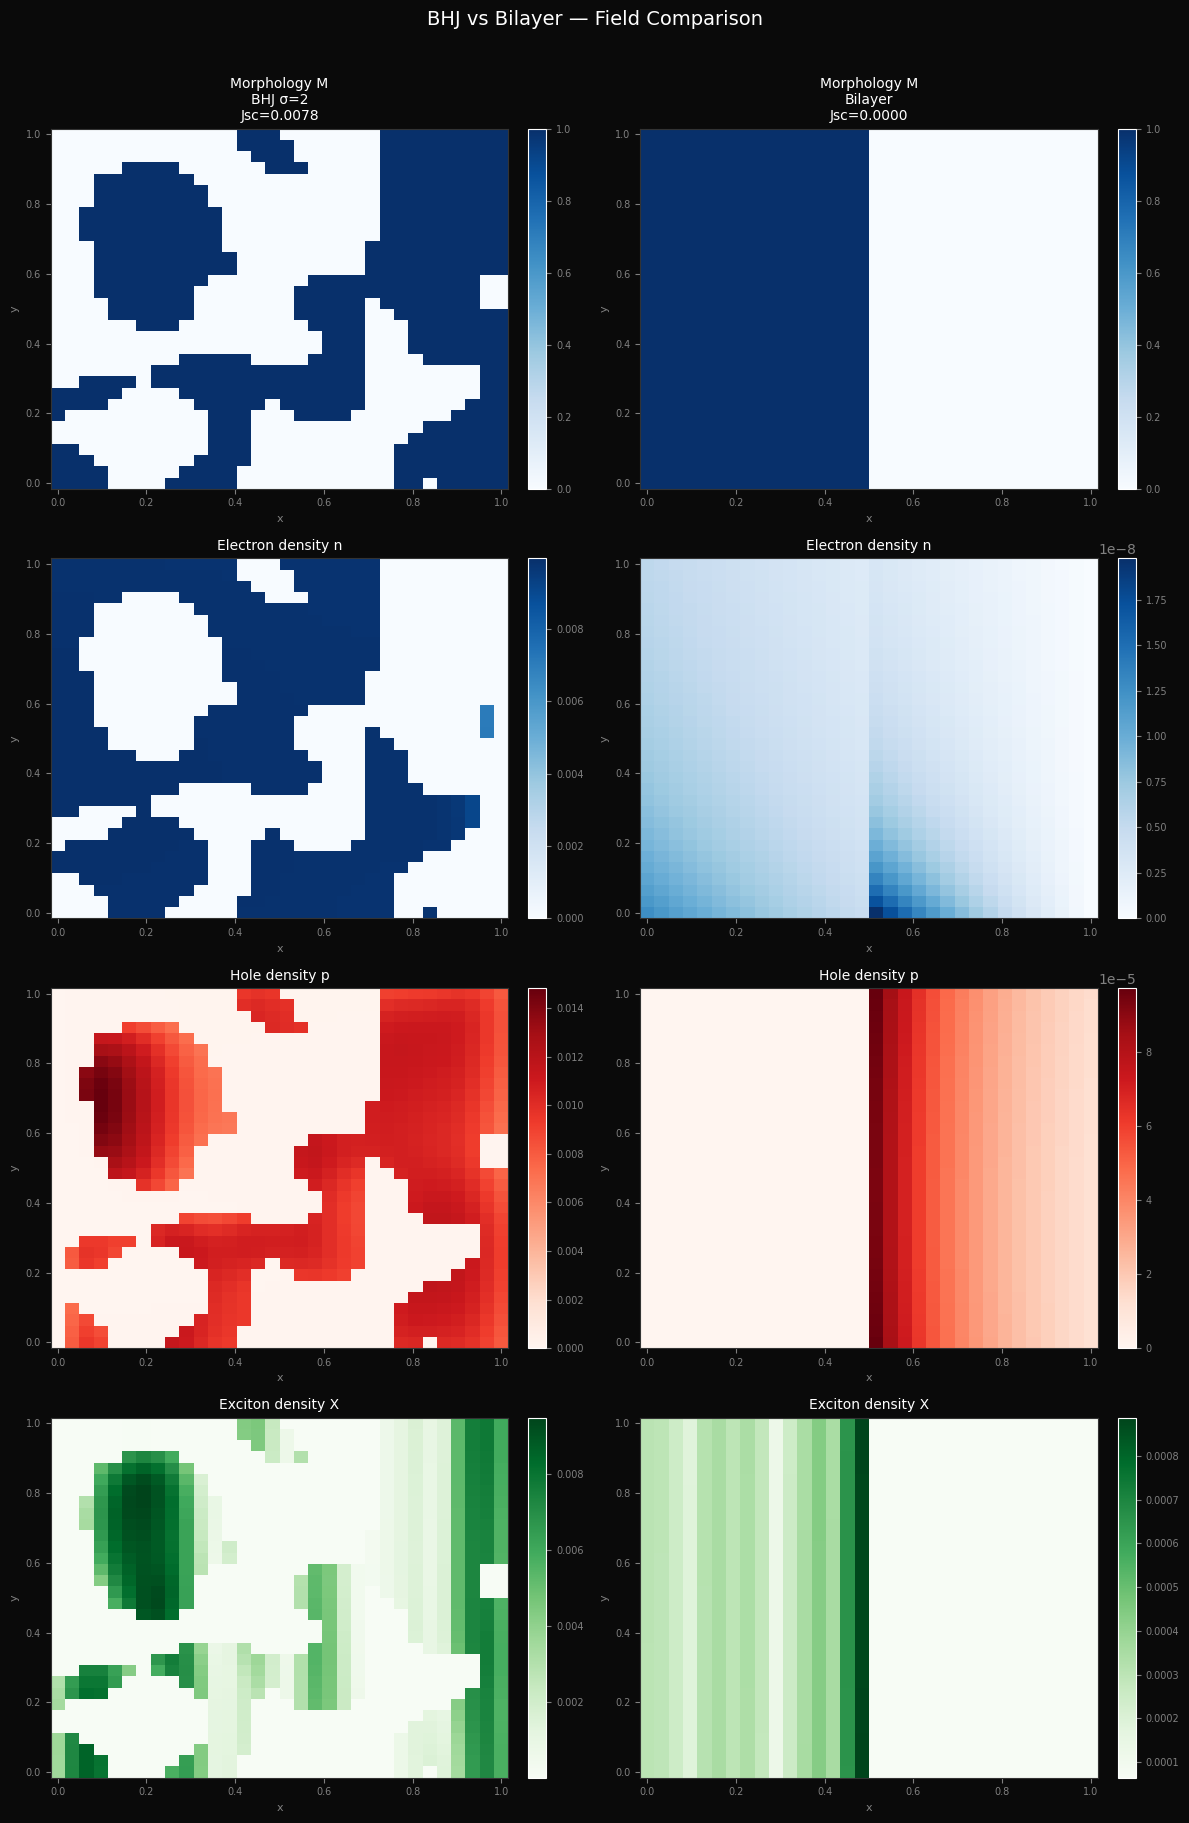

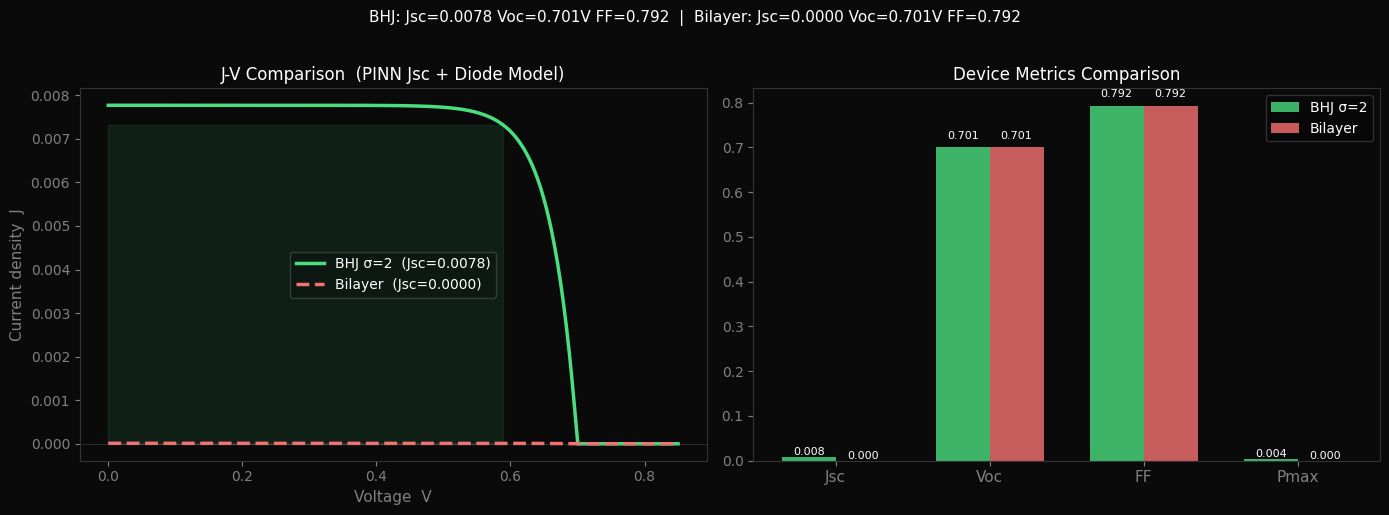


Metric            BHJ σ=2      Bilayer      Ratio
--------------------------------------------------
Interface          21.9%        3.1%
Jsc                0.0078       0.0000     701.5x
Voc                 0.701        0.701
FF                  0.792        0.792
Pmax               0.0043       0.0000     701.5x


In [ ]:
# ============================================
# VISUALIZATION — side by side comparison
# ============================================
BG   = '#0a0a0a'
plt.style.use('dark_background')
x_ax = np.linspace(0, 1, N_grid)
y_ax = np.linspace(0, 1, N_grid)

# --- Figure 1: field comparison ---
fig, axes = plt.subplots(4, 2, figsize=(12, 18))
fig.patch.set_facecolor(BG)

field_rows = [
    ('M',   'Morphology M',          'Blues',  'Blues'),
    ('n',   'Electron density n',    'Blues',  'Blues'),
    ('p',   'Hole density p',        'Reds',   'Reds'),
    ('X',   'Exciton density X',     'Greens', 'Greens'),
]

for row, (key, title, cmap_l, cmap_r) in enumerate(field_rows):
    for col, (fields, label, cmap) in enumerate([
        (fields_bhj,     f'BHJ σ=2\nJsc={Jsc_bhj:.4f}',         cmap_l),
        (fields_bilayer, f'Bilayer\nJsc={Jsc_bilayer:.4f}',       cmap_r),
    ]):
        ax = axes[row, col]
        ax.set_facecolor(BG)
        im = ax.pcolormesh(x_ax, y_ax, fields[key].T,
                           cmap=cmap, shading='auto')
        plt.colorbar(im, ax=ax, fraction=0.046,
                     pad=0.04).ax.tick_params(colors='gray', labelsize=7)
        ax.set_title(f'{title}\n{label}' if row==0 else title,
                     color='white', fontsize=10)
        ax.set_xlabel('x', color='gray', fontsize=8)
        ax.set_ylabel('y', color='gray', fontsize=8)
        ax.tick_params(colors='gray', labelsize=7)
        for s in ax.spines.values(): s.set_edgecolor('#333333')

fig.suptitle('BHJ vs Bilayer — Field Comparison',
             color='white', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('bhj_vs_bilayer_fields.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()

# --- Figure 2: J-V comparison using diode model ---
J0_bhj     = Jsc_bhj     / (np.exp(Voc_target/(n_ideal*Vt_phys)) - 1)
J0_bilayer = Jsc_bilayer / (np.exp(Voc_target/(n_ideal*Vt_phys)) - 1)

V_sweep = np.linspace(0.0, 0.85, 200)

J_bhj     = np.clip(Jsc_bhj     - J0_bhj     * (np.exp(V_sweep/(n_ideal*Vt_phys)) - 1), 0, None)
J_bilayer = np.clip(Jsc_bilayer - J0_bilayer * (np.exp(V_sweep/(n_ideal*Vt_phys)) - 1), 0, None)

def get_metrics(Jsc, J, V):
    sc = np.where(np.diff(np.sign(J)))[0]
    if len(sc) > 0:
        i   = sc[0]
        Voc = V[i] - J[i]*(V[i+1]-V[i])/(J[i+1]-J[i])
    else:
        Voc = Voc_target
    P       = J * V
    idx     = np.argmax(P)
    FF      = P[idx] / (Voc * Jsc) if Voc*Jsc > 0 else 0
    return Voc, P[idx], V[idx], J[idx], FF

Voc_b,  Pmax_b,  Vmpp_b,  Jmpp_b,  FF_b  = get_metrics(Jsc_bhj,     J_bhj,     V_sweep)
Voc_bl, Pmax_bl, Vmpp_bl, Jmpp_bl, FF_bl = get_metrics(Jsc_bilayer, J_bilayer, V_sweep)

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.patch.set_facecolor(BG)

# J-V curves
ax = axes2[0]
ax.set_facecolor(BG)
ax.plot(V_sweep, J_bhj,     color='#4ade80', linewidth=2.5,
        label=f'BHJ σ=2  (Jsc={Jsc_bhj:.4f})')
ax.plot(V_sweep, J_bilayer, color='#f87171', linewidth=2.5,
        linestyle='--', label=f'Bilayer  (Jsc={Jsc_bilayer:.4f})')

# MPP rectangles
ax.fill_between([0, Vmpp_b],  [0,0], [Jmpp_b,  Jmpp_b],
                alpha=0.10, color='#4ade80')
ax.fill_between([0, Vmpp_bl], [0,0], [Jmpp_bl, Jmpp_bl],
                alpha=0.10, color='#f87171')

ax.axhline(y=0, color='gray', linewidth=0.5, alpha=0.4)
ax.set_title('J-V Comparison  (PINN Jsc + Diode Model)',
             color='white', fontsize=12)
ax.set_xlabel('Voltage  V', color='gray', fontsize=11)
ax.set_ylabel('Current density  J', color='gray', fontsize=11)
ax.legend(fontsize=10, framealpha=0.2, labelcolor='white')
ax.tick_params(colors='gray')
for s in ax.spines.values(): s.set_edgecolor('#333333')

# Metrics bar chart
ax2 = axes2[1]
ax2.set_facecolor(BG)

metrics      = ['Jsc', 'Voc', 'FF', 'Pmax']
bhj_vals     = [Jsc_bhj,     Voc_b,  FF_b,  Pmax_b]
bilayer_vals = [Jsc_bilayer, Voc_bl, FF_bl, Pmax_bl]

x_pos = np.arange(len(metrics))
w     = 0.35

bars1 = ax2.bar(x_pos - w/2, bhj_vals,     w,
                color='#4ade80', alpha=0.8, label='BHJ σ=2')
bars2 = ax2.bar(x_pos + w/2, bilayer_vals, w,
                color='#f87171', alpha=0.8, label='Bilayer')

# Value labels on bars
for bar in bars1:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() * 1.02,
             f'{bar.get_height():.3f}',
             ha='center', va='bottom',
             color='white', fontsize=8)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() * 1.02,
             f'{bar.get_height():.3f}',
             ha='center', va='bottom',
             color='white', fontsize=8)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(metrics, color='gray', fontsize=11)
ax2.set_title('Device Metrics Comparison',
              color='white', fontsize=12)
ax2.legend(fontsize=10, framealpha=0.2, labelcolor='white')
ax2.tick_params(colors='gray')
for s in ax2.spines.values(): s.set_edgecolor('#333333')

fig2.suptitle(
    f'BHJ: Jsc={Jsc_bhj:.4f} Voc={Voc_b:.3f}V FF={FF_b:.3f}  |  '
    f'Bilayer: Jsc={Jsc_bilayer:.4f} Voc={Voc_bl:.3f}V FF={FF_bl:.3f}',
    color='white', fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig('bhj_vs_bilayer_jv.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()

# Final summary
print(f"\n{'='*50}")
print(f"{'Metric':<12} {'BHJ σ=2':>12} {'Bilayer':>12} {'Ratio':>10}")
print(f"{'-'*50}")
print(f"{'Interface':<12} {interface_fraction(M_bhj):>11.1%} "
      f"{interface_fraction(M_bilayer):>11.1%}")
print(f"{'Jsc':<12} {Jsc_bhj:>12.4f} {Jsc_bilayer:>12.4f} "
      f"{Jsc_bhj/max(Jsc_bilayer,1e-9):>9.1f}x")
print(f"{'Voc':<12} {Voc_b:>12.3f} {Voc_bl:>12.3f}")
print(f"{'FF':<12} {FF_b:>12.3f} {FF_bl:>12.3f}")
print(f"{'Pmax':<12} {Pmax_b:>12.4f} {Pmax_bl:>12.4f} "
      f"{Pmax_b/max(Pmax_bl,1e-9):>9.1f}x")
print(f"{'='*50}")